In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [3]:
np.random.seed(42)
date_range = pd.date_range(start="2020-01-01", periods=365, freq='D')
temperature = 10 + 15 * np.sin(2 * np.pi * date_range.dayofyear / 365) + np.random.normal(0, 2, size=len(date_range))

weather_data = pd.DataFrame({
    "Date": date_range,
    "Temperature": temperature
})
weather_data.set_index("Date", inplace=True)

In [5]:
weather_data["Lag_1"] = weather_data["Temperature"].shift(1)
weather_data["Lag_2"] = weather_data["Temperature"].shift(2)
weather_data.dropna(inplace=True)

X = weather_data[["Lag_1", "Lag_2"]]
y = weather_data["Temperature"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
tscv = TimeSeriesSplit(n_splits=5)
results = []
split_vis = []

In [9]:
for i, (train_index, test_index) in enumerate(tscv.split(X_scaled)):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    results.append((i+1, mae, rmse))

    split_vis.append((train_index, test_index))

results_df = pd.DataFrame(results, columns=["Fold", "MAE", "RMSE"])
print(results_df)

   Fold       MAE      RMSE
0     1  1.962142  2.346788
1     2  2.076151  2.587592
2     3  2.319426  3.004967
3     4  2.045766  2.627879
4     5  1.501068  1.858754


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use 

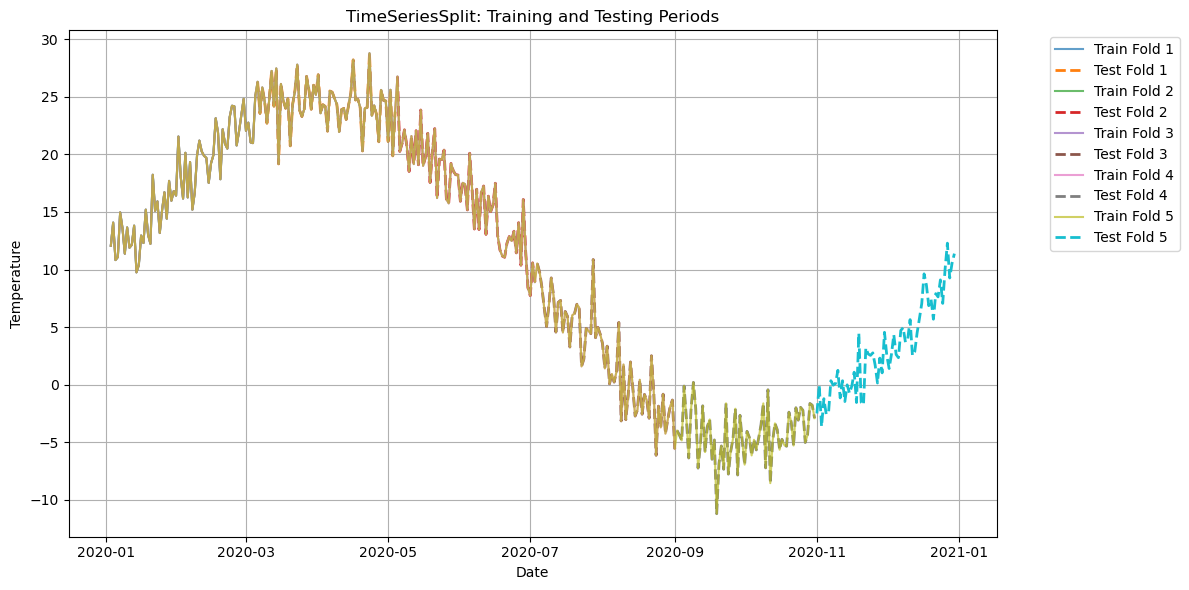

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i, (train_index, test_index) in enumerate(split_vis):
    plt.plot(weather_data.index[train_index], y.iloc[train_index], label=f"Train Fold {i+1}", alpha=0.7)
    plt.plot(weather_data.index[test_index], y.iloc[test_index], label=f"Test Fold {i+1}", linestyle='--', linewidth=2)

plt.title("TimeSeriesSplit: Training and Testing Periods")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.grid(True)
plt.show()


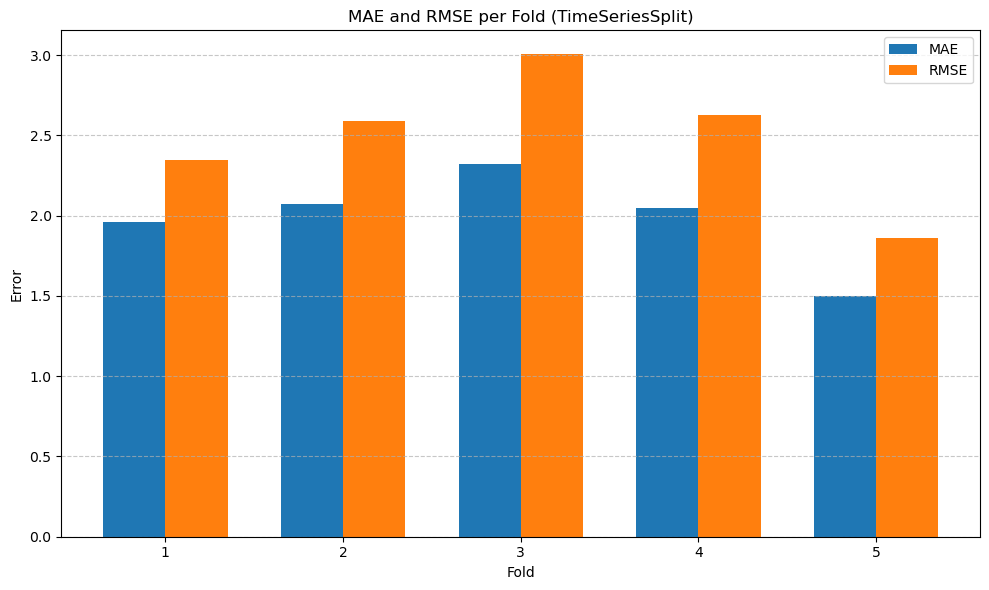

In [15]:
import matplotlib.pyplot as plt
import numpy as np

x = results_df["Fold"]
mae = results_df["MAE"]
rmse = results_df["RMSE"]

bar_width = 0.35
index = np.arange(len(x))

plt.figure(figsize=(10, 6))
plt.bar(index, mae, bar_width, label='MAE')
plt.bar(index + bar_width, rmse, bar_width, label='RMSE')

plt.xlabel("Fold")
plt.ylabel("Error")
plt.title("MAE and RMSE per Fold (TimeSeriesSplit)")
plt.xticks(index + bar_width / 2, x)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()
